# 02 — Feature Engineering & Daten-Split

**Scope:** Neue Features erstellen, Encoding, Feature-Uebersicht, Train/Test-Split.

Die aufbereiteten Daten werden in `data/processed/` gespeichert.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_prep import (
    load_raw_data, clean_data, add_features,
    collapse_no_service, encode_features, get_X_y,
    SERVICE_COLS, CATEGORICAL_COLS, NUMERIC_COLS,
)
from src.modeling import split_data

sns.set_theme(style="whitegrid", font_scale=1.2)
plt.rcParams["figure.dpi"] = 300
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["figure.figsize"] = (10, 6)

---
## 3.1 Daten laden und bereinigen

In [2]:
df_raw = load_raw_data()
df = clean_data(df_raw)
print(f"Shape nach Bereinigung: {df.shape}")
df.head()

Shape nach Bereinigung: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 3.2 Neue Features erstellen

In [3]:
df = add_features(df)

new_features = ["ServiceCount", "AvgMonthlySpend", "SeniorAlone", "HasSupport", "HasStreaming", "tenure_group", "HighSpender"]
print("Neue Features:")
df[new_features].describe()

Neue Features:


,ServiceCount,AvgMonthlySpend,SeniorAlone,HasSupport,HasStreaming,HighSpender
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,2.037910,64.762906,0.079654,0.420843,0.496805,0.499077
std,1.847682,30.189796,0.270775,0.493730,0.500025,0.500035
min,0.000000,13.775000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,35.935156,0.000000,0.000000,0.000000,0.000000
50%,2.000000,70.337500,0.000000,0.000000,0.000000,0.000000
75%,3.000000,90.174158,0.000000,1.000000,1.000000,1.000000
max,6.000000,121.400000,1.000000,1.000000,1.000000,1.000000


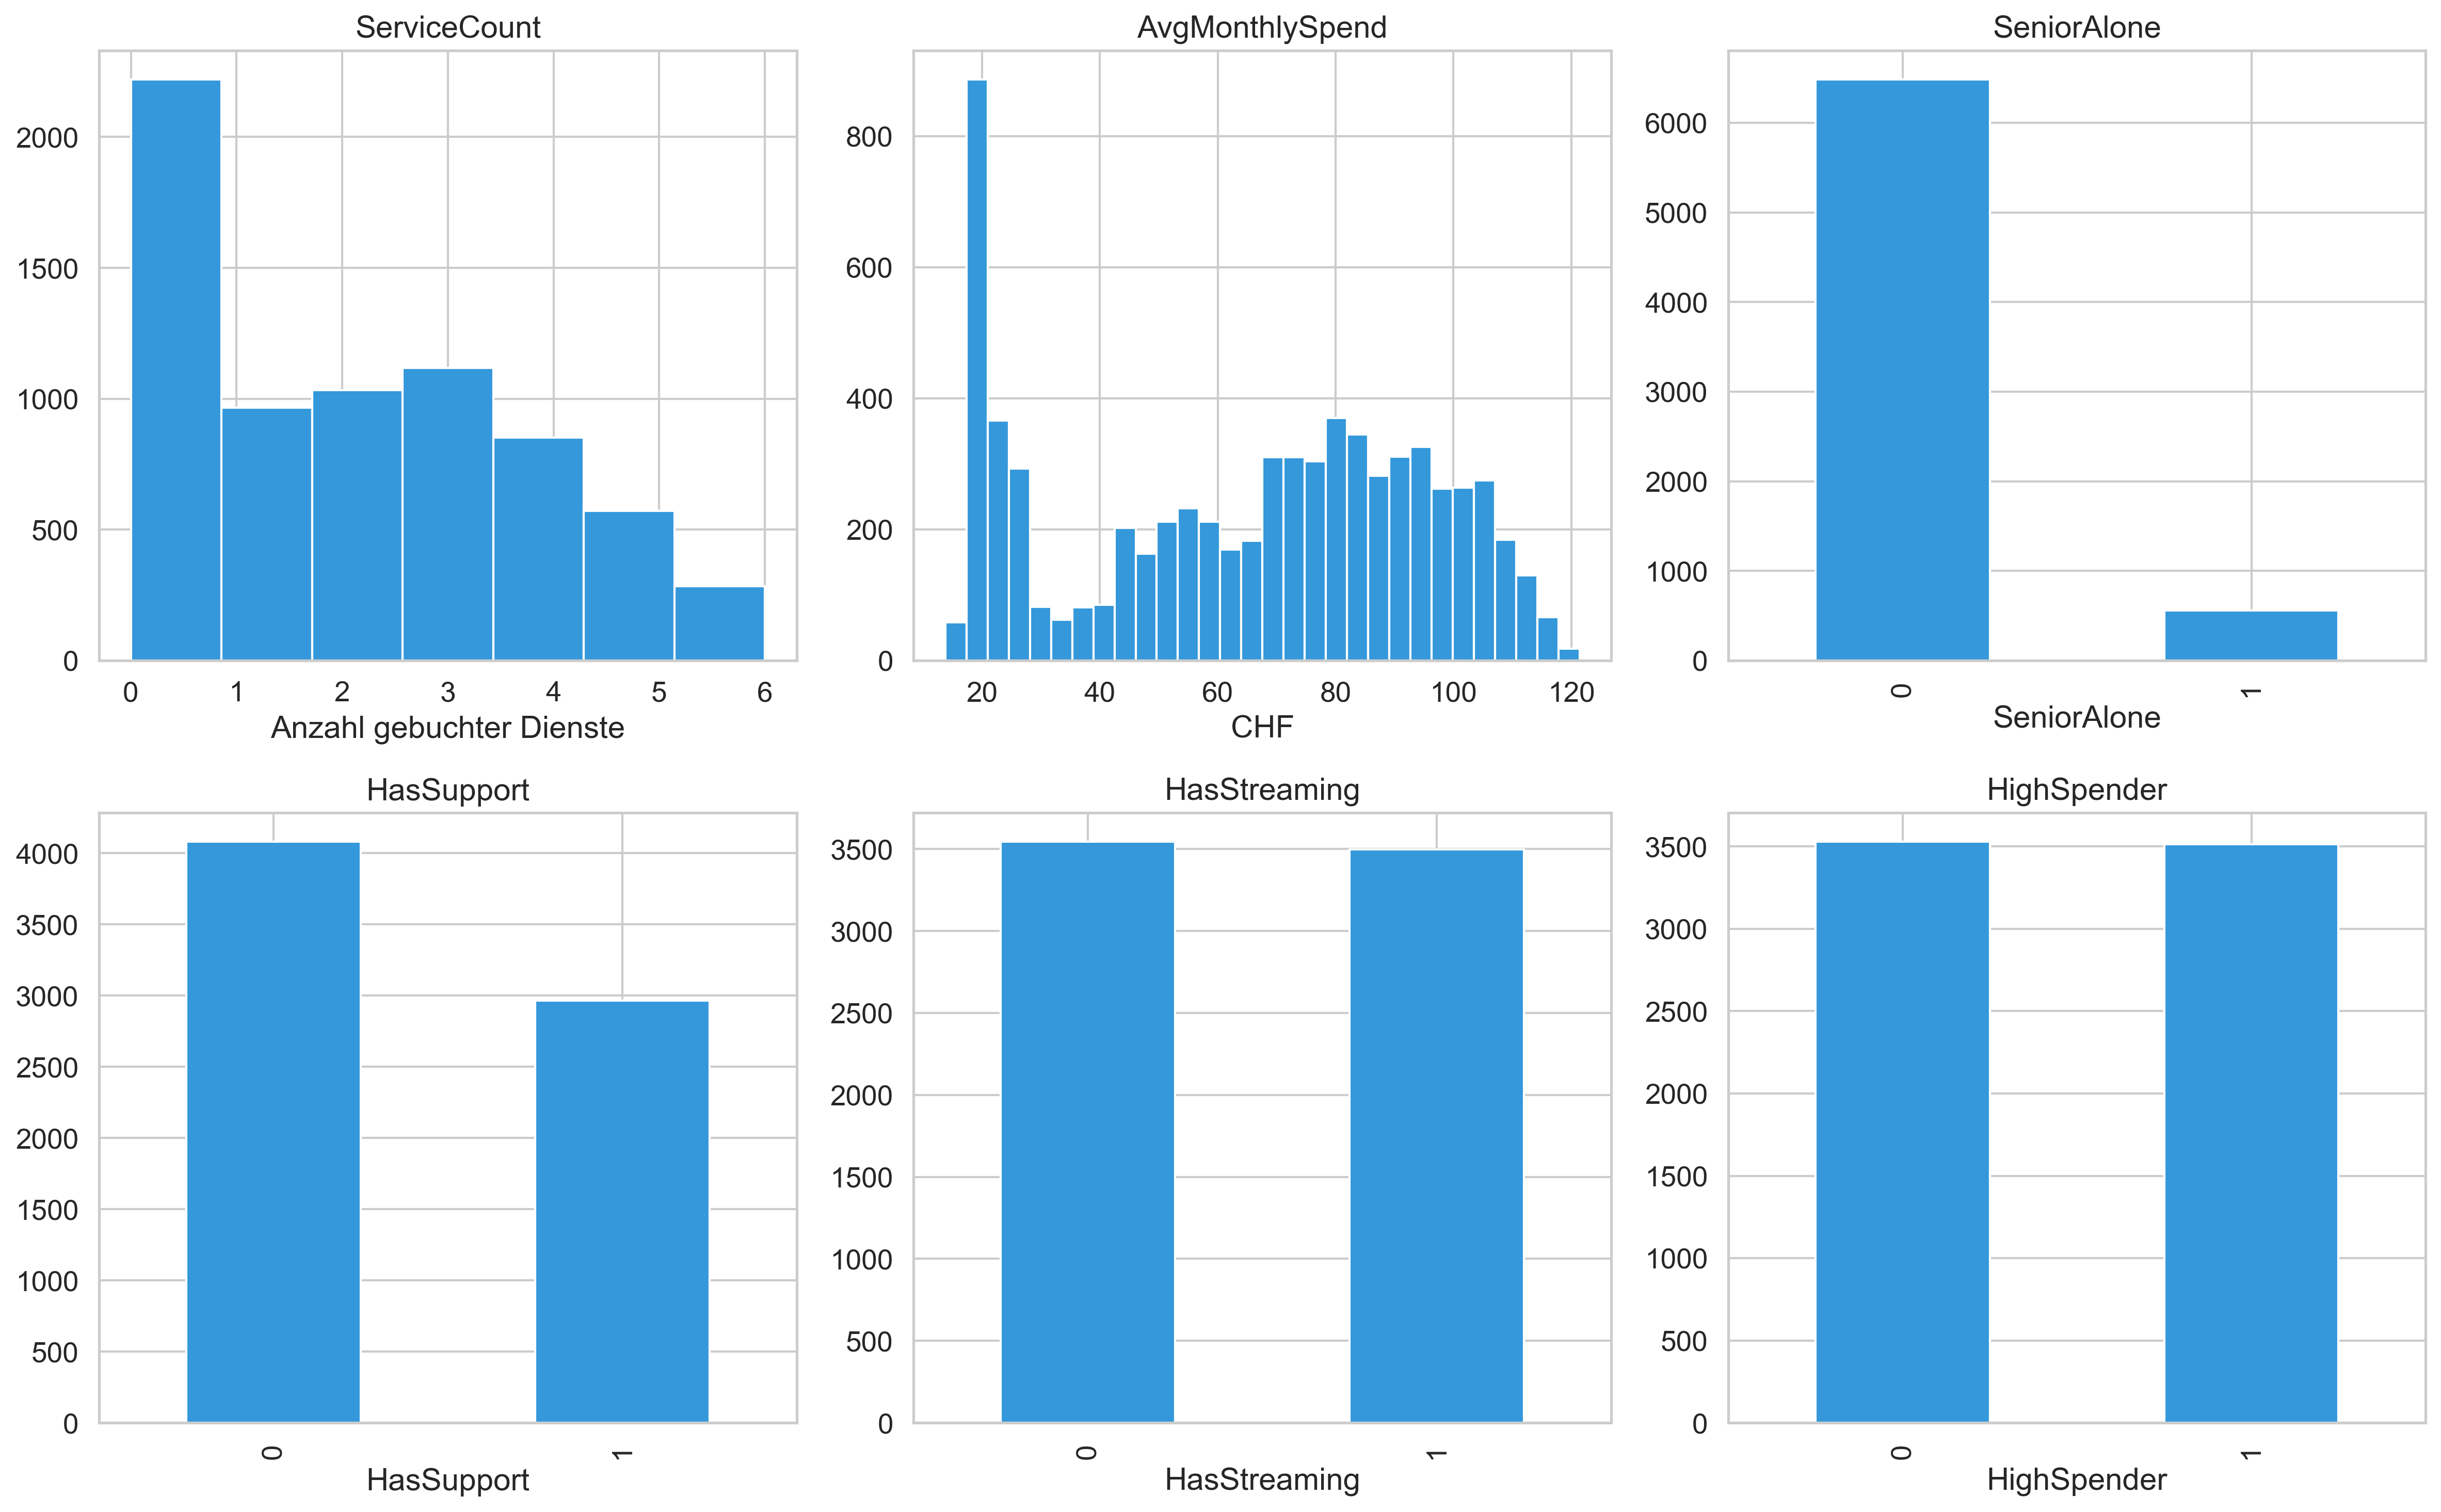

In [4]:
# Plausibilitaetspruefung: Verteilung der neuen Features
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

axes[0, 0].hist(df["ServiceCount"], bins=7, color="#3498db", edgecolor="white")
axes[0, 0].set_title("ServiceCount")
axes[0, 0].set_xlabel("Anzahl gebuchter Dienste")

axes[0, 1].hist(df["AvgMonthlySpend"], bins=30, color="#3498db", edgecolor="white")
axes[0, 1].set_title("AvgMonthlySpend")
axes[0, 1].set_xlabel("CHF")

df["SeniorAlone"].value_counts().plot.bar(ax=axes[0, 2], color="#3498db")
axes[0, 2].set_title("SeniorAlone")

df["HasSupport"].value_counts().plot.bar(ax=axes[1, 0], color="#3498db")
axes[1, 0].set_title("HasSupport")

df["HasStreaming"].value_counts().plot.bar(ax=axes[1, 1], color="#3498db")
axes[1, 1].set_title("HasStreaming")

df["HighSpender"].value_counts().plot.bar(ax=axes[1, 2], color="#3498db")
axes[1, 2].set_title("HighSpender")

plt.tight_layout()
plt.show()

## 3.3 Encoding

In [5]:
# "No internet service" / "No phone service" mit "No" zusammenfassen
df = collapse_no_service(df)

# Pruefen
print("MultipleLines unique:", df["MultipleLines"].unique())
print("OnlineSecurity unique:", df["OnlineSecurity"].unique())

MultipleLines unique: ['No' 'Yes']
OnlineSecurity unique: ['No' 'Yes']


In [6]:
# One-Hot-Encoding
df_encoded = encode_features(df)

print(f"Shape vor Encoding:  {df.shape}")
print(f"Shape nach Encoding: {df_encoded.shape}")
print(f"\nAlle Spalten ({len(df_encoded.columns)}):")
for i, col in enumerate(df_encoded.columns, 1):
    print(f"  {i:2d}. {col}")

Shape vor Encoding:  (7043, 27)
Shape nach Encoding: (7043, 33)

Alle Spalten (33):
   1. SeniorCitizen
   2. tenure
   3. MonthlyCharges
   4. TotalCharges
   5. Churn
   6. ServiceCount
   7. AvgMonthlySpend
   8. SeniorAlone
   9. HasSupport
  10. HasStreaming
  11. HighSpender
  12. gender_Male
  13. Partner_Yes
  14. Dependents_Yes
  15. PhoneService_Yes
  16. MultipleLines_Yes
  17. InternetService_Fiber optic
  18. InternetService_No
  19. OnlineSecurity_Yes
  20. OnlineBackup_Yes
  21. DeviceProtection_Yes
  22. TechSupport_Yes
  23. StreamingTV_Yes
  24. StreamingMovies_Yes
  25. Contract_One year
  26. Contract_Two year
  27. PaperlessBilling_Yes
  28. PaymentMethod_Credit card (automatic)
  29. PaymentMethod_Electronic check
  30. PaymentMethod_Mailed check
  31. tenure_group_13-24
  32. tenure_group_25-48
  33. tenure_group_49-72


## 4. Train/Test-Split

In [7]:
X, y = get_X_y(df_encoded)
X_train, X_test, y_train, y_test = split_data(X, y)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"\nChurn-Verteilung Training: {y_train.mean():.3f}")
print(f"Churn-Verteilung Test:     {y_test.mean():.3f}")

X_train: (4930, 32)
X_test:  (2113, 32)

Churn-Verteilung Training: 0.265
Churn-Verteilung Test:     0.265


In [8]:
# Daten speichern fuer nachfolgende Notebooks
X_train.to_csv("data/processed/X_train.csv", index=False)
X_test.to_csv("data/processed/X_test.csv", index=False)
y_train.to_csv("data/processed/y_train.csv", index=False)
y_test.to_csv("data/processed/y_test.csv", index=False)

print("Daten gespeichert in data/processed/")
print(f"Features: {X_train.shape[1]}")
print(f"Feature-Namen: {list(X_train.columns)}")

Daten gespeichert in data/processed/
Features: 32
Feature-Namen: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'ServiceCount', 'AvgMonthlySpend', 'SeniorAlone', 'HasSupport', 'HasStreaming', 'HighSpender', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes', 'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'tenure_group_13-24', 'tenure_group_25-48', 'tenure_group_49-72']


---
## Zusammenfassung Feature Engineering

- 7 neue Features erstellt (ServiceCount, AvgMonthlySpend, SeniorAlone, HasSupport, HasStreaming, tenure_group, HighSpender)
- "No internet service" / "No phone service" mit "No" zusammengefasst
- One-Hot-Encoding durchgefuehrt
- 70/30 Stratified Split (gleicher Split fuer alle Modelle)
- Daten in data/processed/ gespeichert